# Exercice 1.3 : Découverte de NetworkX

Chargement, analyse et visualisation du réseau du club de karaté de Zachary (*Zachary's Karate Club*).

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Charger le réseau 'Zachary's Karate Club'
G = nx.karate_club_graph()

# Afficher le nombre de nœuds et d'arêtes
print(f"Nombre de nœuds : {G.number_of_nodes()}")
print(f"Nombre d'arêtes : {G.number_of_edges()}")

# 2. Calculer et afficher les 5 nœuds ayant le plus haut degré
top_5_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 des nœuds avec le plus haut degré (plus de connexions) :")
for node, degree in top_5_nodes:
    print(f" - Nœud {node} : {degree} connexions")

# 3. Dessiner le réseau avec affichage des numéros des nœuds
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='skyblue', edge_color='gray', node_size=600, font_weight='bold')
plt.title("Zachary's Karate Club Network")
plt.show()

## Partie 2 : Matrices d'adjacence, Graphes orientés/non-orientés, Poids, Isolats et Boucles

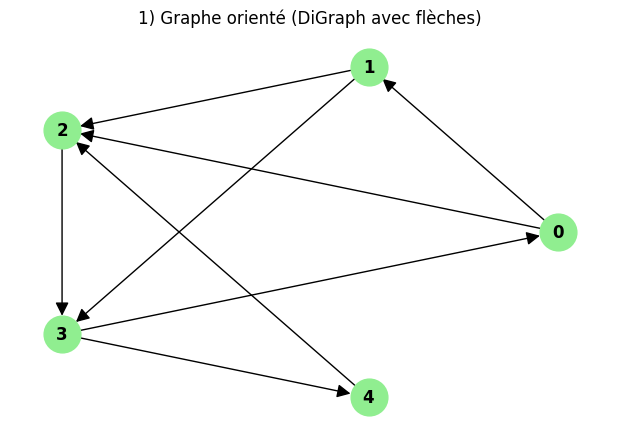

=== Comparaison Sommes Matrice vs Degrés NetworkX ===
Nœud  Somme Ligne   Out-Degree  Somme Colonne   In-Degree 
0     2             2           1               1         
1     2             2           1               1         
2     1             1           3               3         
3     2             2           2               2         
4     1             1           1               1         

Correspondance Sommes Lignes == Out-degrees : True
Correspondance Sommes Colonnes == In-degrees : True


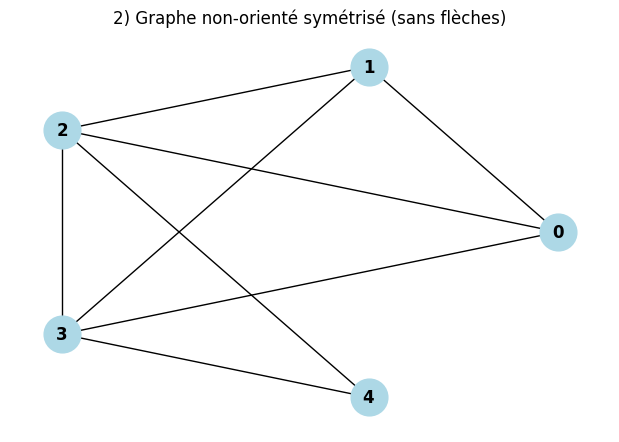

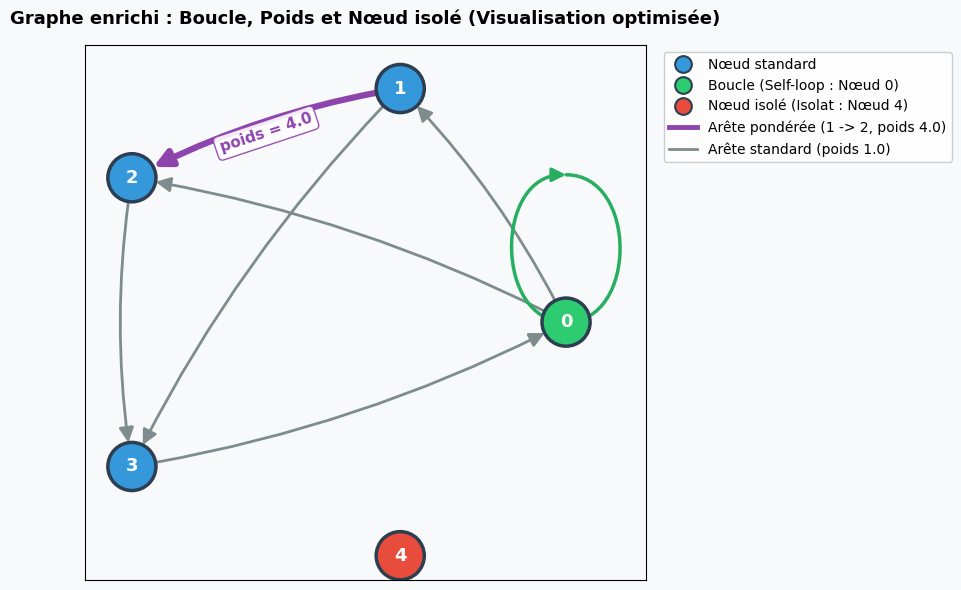


=== Synthèse des caractéristiques ===
• Boucle (self-loop) : Nœud 0 (0 -> 0)
• Nœud isolé (isolate) : Nœud 4 (aucune connexion)
• Arête pondérée : 1 -> 2 (poids = 4.0)


In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Matrice 5x5 définie à la main (NumPy array)
A = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [1, 0, 0, 0, 1],
    [0, 0, 1, 0, 0]
])

# 2. Conversion en graphe orienté (DiGraph)
G_dir = nx.from_numpy_array(A, create_using=nx.DiGraph)

# 3. Tracé du graphe orienté (avec flèches)
pos_circ = nx.circular_layout(G_dir)
plt.figure(figsize=(6, 4))
nx.draw(G_dir, pos_circ, with_labels=True, node_color='lightgreen', node_size=700, font_weight='bold', arrows=True, arrowsize=20)
plt.title("1) Graphe orienté (DiGraph avec flèches)")
plt.show()

# 4. Sommes des lignes/colonnes vs out_degree/in_degree de NetworkX
row_sums = A.sum(axis=1)      # Somme des lignes = degrés sortants (out-degree)
col_sums = A.sum(axis=0)      # Somme des colonnes = degrés entrants (in-degree)

out_degrees = [G_dir.out_degree(i) for i in range(5)]
in_degrees = [G_dir.in_degree(i) for i in range(5)]

print("=== Comparaison Sommes Matrice vs Degrés NetworkX ===")
print(f"{'Nœud':<6}{'Somme Ligne':<14}{'Out-Degree':<12}{'Somme Colonne':<16}{'In-Degree':<10}")
for i in range(5):
    print(f"{i:<6}{row_sums[i]:<14}{out_degrees[i]:<12}{col_sums[i]:<16}{in_degrees[i]:<10}")

print(f"\nCorrespondance Sommes Lignes == Out-degrees : {np.array_equal(row_sums, out_degrees)}")
print(f"Correspondance Sommes Colonnes == In-degrees : {np.array_equal(col_sums, in_degrees)}")

# 5. Symétrisation de la matrice (A + A^T, écrêtée à 1)
A_sym = np.clip(A + A.T, 0, 1)

# 6. Construction d'un graphe non-orienté et tracé (sans flèches)
G_undir = nx.from_numpy_array(A_sym, create_using=nx.Graph)

plt.figure(figsize=(6, 4))
nx.draw(G_undir, pos_circ, with_labels=True, node_color='lightblue', node_size=700, font_weight='bold')
plt.title("2) Graphe non-orienté symétrisé (sans flèches)")
plt.show()

# 7. Ajout d'un poids, d'un nœud isolé et d'une boucle (self-loop)
A_mod = A.copy().astype(float)

# - Boucle (self-loop) sur le nœud 0
A_mod[0, 0] = 1.0

# - Poids augmenté sur l'arête (1 -> 2)
A_mod[1, 2] = 4.0

# - Nœud isolé (nœud 4 : ligne et colonne à 0)
A_mod[4, :] = 0.0
A_mod[:, 4] = 0.0

G_mod = nx.from_numpy_array(A_mod, create_using=nx.DiGraph)

# --- Visualisation améliorée, claire et soignée ---
plt.figure(figsize=(9, 6), facecolor='#f8f9fa')
ax = plt.gca()
ax.set_facecolor('#f8f9fa')

# Couleurs distinctives par type de nœud
node_colors = []
for node in G_mod.nodes():
    if node in nx.isolates(G_mod):
        node_colors.append('#e74c3c')       # Rouge corail pour l'isolat (Nœud 4)
    elif node in nx.nodes_with_selfloops(G_mod):
        node_colors.append('#2ecc71')       # Vert pour le nœud avec self-loop (Nœud 0)
    else:
        node_colors.append('#3498db')       # Bleu pour les nœuds standards (1, 2, 3)

# Dessin des nœuds avec bordures nettes
nx.draw_networkx_nodes(
    G_mod, pos_circ,
    node_color=node_colors,
    node_size=1200,
    edgecolors='#2c3e50',
    linewidths=2.5,
    ax=ax
)

# Labels des nœuds (texte blanc lisible)
nx.draw_networkx_labels(
    G_mod, pos_circ,
    font_size=13,
    font_weight='bold',
    font_color='white',
    ax=ax
)

# Catégorisation des arêtes
standard_edges = [(u, v) for u, v, d in G_mod.edges(data=True) if u != v and d['weight'] == 1.0]
weighted_edges = [(u, v) for u, v, d in G_mod.edges(data=True) if u != v and d['weight'] > 1.0]
self_loop_edges = [(u, v) for u, v in G_mod.edges() if u == v]

# 1) Arêtes standards (grises)
nx.draw_networkx_edges(
    G_mod, pos_circ,
    edgelist=standard_edges,
    edge_color='#7f8c8d',
    width=2,
    arrows=True,
    arrowsize=22,
    arrowstyle='-|>',
    node_size=1200,
    connectionstyle='arc3,rad=0.08',
    ax=ax
)

# 2) Arête pondérée (violette et épaisse)
nx.draw_networkx_edges(
    G_mod, pos_circ,
    edgelist=weighted_edges,
    edge_color='#8e44ad',
    width=4.5,
    arrows=True,
    arrowsize=26,
    arrowstyle='-|>',
    node_size=1200,
    connectionstyle='arc3,rad=0.08',
    ax=ax
)

# 3) Boucle / Self-loop (verte)
nx.draw_networkx_edges(
    G_mod, pos_circ,
    edgelist=self_loop_edges,
    edge_color='#27ae60',
    width=2.5,
    arrows=True,
    arrowsize=20,
    arrowstyle='-|>',
    node_size=1200,
    ax=ax
)

# Étiquettes de poids avec fond blanc clair
edge_labels = {(u, v): f"poids = {d['weight']:.1f}" for u, v, d in G_mod.edges(data=True) if u != v and d['weight'] > 1.0}
nx.draw_networkx_edge_labels(
    G_mod, pos_circ,
    edge_labels=edge_labels,
    font_color='#8e44ad',
    font_size=11,
    font_weight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#8e44ad', alpha=0.9),
    ax=ax
)

# Légende explicative dédiée
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Nœud standard', markerfacecolor='#3498db', markersize=12, markeredgecolor='#2c3e50', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', label='Boucle (Self-loop : Nœud 0)', markerfacecolor='#2ecc71', markersize=12, markeredgecolor='#2c3e50', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', label='Nœud isolé (Isolat : Nœud 4)', markerfacecolor='#e74c3c', markersize=12, markeredgecolor='#2c3e50', markeredgewidth=1.5),
    Line2D([0], [0], color='#8e44ad', lw=3.5, label='Arête pondérée (1 -> 2, poids 4.0)'),
    Line2D([0], [0], color='#7f8c8d', lw=2, label='Arête standard (poids 1.0)')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, facecolor='white', edgecolor='#bdc3c7', fontsize=10)

plt.title("Graphe enrichi : Boucle, Poids et Nœud isolé (Visualisation optimisée)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n=== Synthèse des caractéristiques ===")
print(f"• Boucle (self-loop) : Nœud {list(nx.nodes_with_selfloops(G_mod))[0]} (0 -> 0)")
print(f"• Nœud isolé (isolate) : Nœud {list(nx.isolates(G_mod))[0]} (aucune connexion)")
print(f"• Arête pondérée : 1 -> 2 (poids = {G_mod[1][2]['weight']})")